# 14 — CNN Fundamentals

Modules 10-13 treated every input as a flat vector of features — fine for
tabular data, but wasteful for images: flattening an image throws away the
fact that nearby pixels are related, and a fully-connected layer needs a
separate weight for every pixel, in every position, learned independently.
**Convolutional Neural Networks (CNNs)** fix both problems with one idea: a
small filter, slid across the whole image, reusing the *same* weights at
every position.

We'll use `load_digits` (the same dataset Module 11's MLP trained on) so the
parameter-count and accuracy comparison at the end is direct and fair.

**Covered:**
1. The convolution operation, from first principles
2. Pooling
3. Building a small CNN with `nn.Conv2d`
4. Training & evaluating, vs. Module 11's MLP
5. Visualizing learned filters and feature maps

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

sns.set_theme(style="whitegrid")
torch.manual_seed(14)
rng = np.random.default_rng(14)

## 1. The Convolution Operation

**Theory.** A convolution slides a small **filter** (a.k.a. kernel — e.g.
3x3) across an image, computing a weighted sum of each local patch of
pixels at every position, producing a **feature map**. Because the *same*
filter is reused everywhere, a convolution:
- needs far fewer parameters than a fully-connected layer over the same input,
- naturally detects the same pattern (an edge, a corner) regardless of where it appears in the image (translation invariance).

Before training anything, let's apply a couple of hand-designed filters —
one classic edge detector, one blur — to see directly what "sliding a
filter" actually produces.

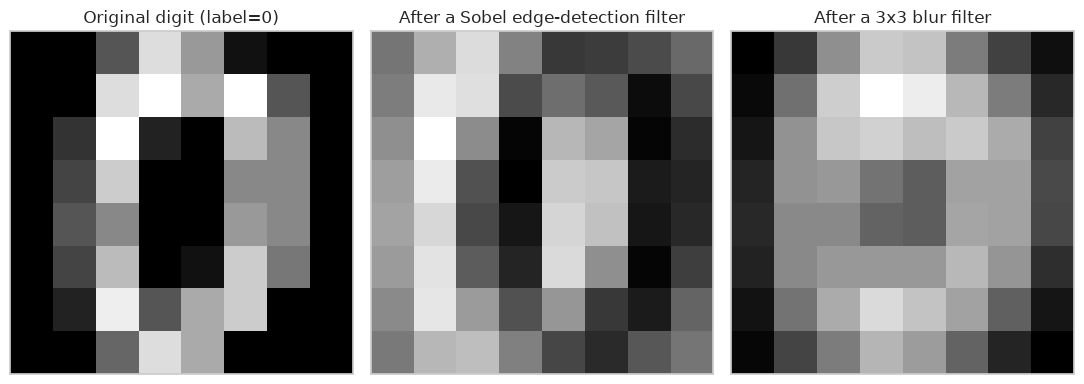

In [2]:
from sklearn.datasets import load_digits

digits = load_digits()
sample_image = torch.tensor(digits.images[0], dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # shape (1, 1, 8, 8): (batch, channel, H, W)

sobel_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
blur = torch.ones(1, 1, 3, 3) / 9.0

edge_map = F.conv2d(sample_image, sobel_x, padding=1)
blur_map = F.conv2d(sample_image, blur, padding=1)

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(sample_image[0, 0], cmap="gray")
axes[0].set_title(f"Original digit (label={digits.target[0]})")
axes[1].imshow(edge_map[0, 0].detach(), cmap="gray")
axes[1].set_title("After a Sobel edge-detection filter")
axes[2].imshow(blur_map[0, 0].detach(), cmap="gray")
axes[2].set_title("After a 3x3 blur filter")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Same mechanism (`F.conv2d`), two completely different effects — purely
from the 9 numbers inside each 3x3 filter. A CNN's convolutional layers
**learn** filters like these from data via backpropagation, instead of us
hand-designing them; section 5 will show what the network actually learns.

**Stride** (how far the filter moves each step) and **padding** (how much
zero-border to add) control the output size:

In [3]:
x = sample_image
print(f"Input shape: {tuple(x.shape)}")
print(f"padding=1, stride=1 -> output shape: {tuple(F.conv2d(x, sobel_x, padding=1, stride=1).shape)}  (same size as input)")
print(f"padding=0, stride=1 -> output shape: {tuple(F.conv2d(x, sobel_x, padding=0, stride=1).shape)}  (shrinks: no border padding)")
print(f"padding=1, stride=2 -> output shape: {tuple(F.conv2d(x, sobel_x, padding=1, stride=2).shape)}  (shrinks: skips positions)")

Input shape: (1, 1, 8, 8)
padding=1, stride=1 -> output shape: (1, 1, 8, 8)  (same size as input)
padding=0, stride=1 -> output shape: (1, 1, 6, 6)  (shrinks: no border padding)
padding=1, stride=2 -> output shape: (1, 1, 4, 4)  (shrinks: skips positions)


## 2. Pooling

**Theory.** Pooling downsamples a feature map by summarizing small
neighborhoods (e.g., a 2x2 block) into a single value — **max pooling**
takes the strongest activation in each block, **average pooling** takes the
mean. This reduces spatial size (and computation) for later layers, and
adds a small amount of translation invariance: a feature shifting by a
pixel or two often still produces the same pooled output.

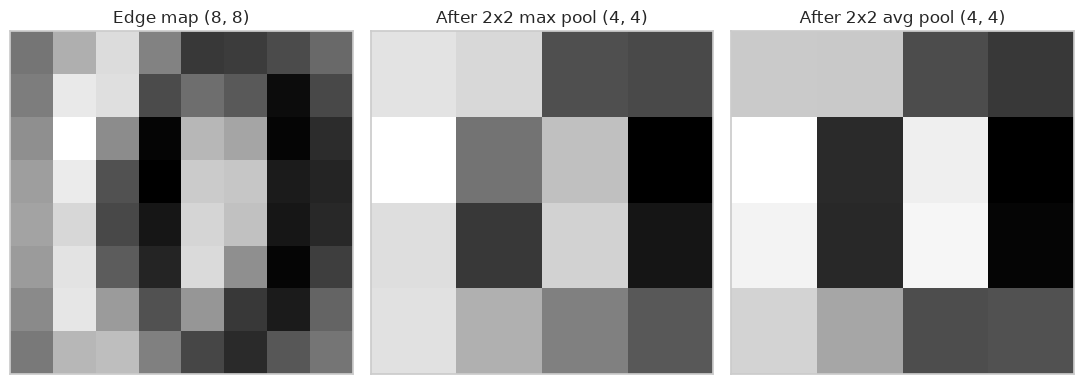

In [4]:
maxpool_map = F.max_pool2d(edge_map, kernel_size=2)
avgpool_map = F.avg_pool2d(edge_map, kernel_size=2)

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(edge_map[0, 0].detach(), cmap="gray")
axes[0].set_title(f"Edge map {tuple(edge_map.shape[2:])}")
axes[1].imshow(maxpool_map[0, 0].detach(), cmap="gray")
axes[1].set_title(f"After 2x2 max pool {tuple(maxpool_map.shape[2:])}")
axes[2].imshow(avgpool_map[0, 0].detach(), cmap="gray")
axes[2].set_title(f"After 2x2 avg pool {tuple(avgpool_map.shape[2:])}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Both pooled maps are exactly half the height and width of the input, with
the strongest edges still clearly visible — most of the information that
mattered (where the strong edges are) survives the compression.

## 3. Building a Small CNN

**Theory.** A typical CNN stacks `Conv -> activation -> Pool` blocks
(learning progressively more abstract features: edges, then shapes, then
digit-like patterns) before flattening down to a small fully-connected
"head" that makes the final classification — combining what convolutions
are good at (spatial pattern detection) with what dense layers are good at
(combining those patterns into a decision).

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # 1 input channel (grayscale) -> 8 feature maps
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # 8 -> 16 feature maps
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(16 * 2 * 2, n_classes)  # 8x8 -> pool -> 4x4 -> pool -> 2x2

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 8x8 -> 4x4
        x = self.pool(F.relu(self.conv2(x)))  # 4x4 -> 2x2
        x = x.flatten(1)
        return self.fc(x)

cnn = SimpleCNN()
from torchinfo import summary
summary(cnn, input_size=(1, 1, 8, 8), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
SimpleCNN                                [1, 1, 8, 8]              [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 8, 8]              [1, 8, 8, 8]              80
├─MaxPool2d: 1-2                         [1, 8, 8, 8]              [1, 8, 4, 4]              --
├─Conv2d: 1-3                            [1, 8, 4, 4]              [1, 16, 4, 4]             1,168
├─MaxPool2d: 1-4                         [1, 16, 4, 4]             [1, 16, 2, 2]             --
├─Linear: 1-5                            [1, 64]                   [1, 10]                   650
Total params: 1,898
Trainable params: 1,898
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

## 4. Training & Evaluating, vs. Module 11's MLP

Same `load_digits` train/test split, same evaluation approach as Module 11
— this time feeding 2D images (`1x8x8`) directly instead of flattening
them to a 64-length vector first.

In [6]:
from sklearn.model_selection import train_test_split

images = digits.images.astype(np.float32)
labels = digits.target

img_train, img_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=14, stratify=labels)

mean, std = img_train.mean(), img_train.std()
X_train = torch.tensor((img_train - mean) / std).unsqueeze(1)  # (N, 1, 8, 8)
X_test = torch.tensor((img_test - mean) / std).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [7]:
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(X_train, y_train_t), batch_size=32, shuffle=True)

torch.manual_seed(14)
cnn = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

n_epochs = 30
train_losses, test_accuracies = [], []
for epoch in range(n_epochs):
    cnn.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(cnn(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_losses.append(epoch_loss / len(X_train))

    cnn.eval()
    with torch.no_grad():
        acc = (cnn(X_test).argmax(1) == y_test_t).float().mean().item()
    test_accuracies.append(acc)

print(f"Final test accuracy: {test_accuracies[-1]:.3f}")
print(f"CNN parameter count: {sum(p.numel() for p in cnn.parameters()):,}")
print(f"(Module 11's MLP with hidden_sizes=[32, 16] had {64*32 + 32 + 32*16 + 16 + 16*10 + 10:,} parameters and reached ~0.97 accuracy)")

Final test accuracy: 0.981
CNN parameter count: 1,898
(Module 11's MLP with hidden_sizes=[32, 16] had 2,778 parameters and reached ~0.97 accuracy)


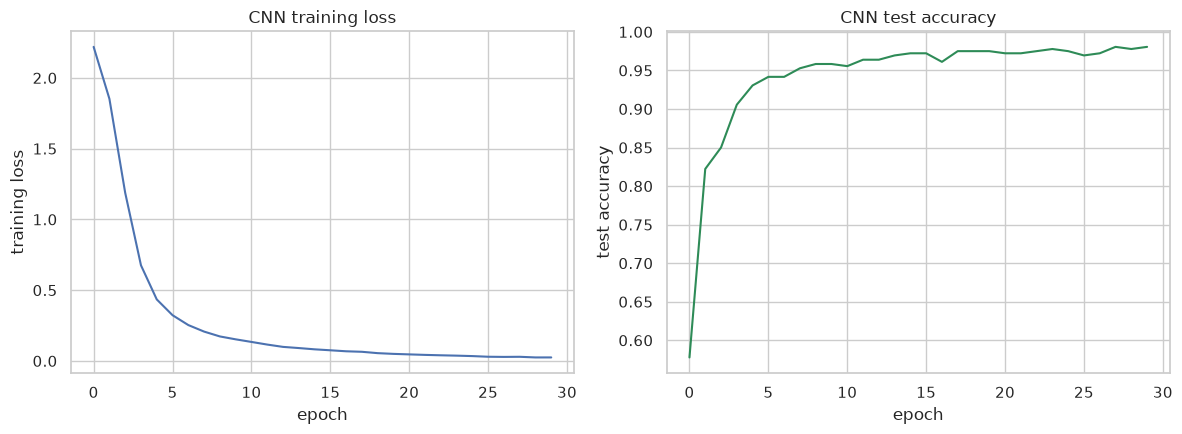

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(train_losses)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss")
axes[0].set_title("CNN training loss")

axes[1].plot(test_accuracies, color="seagreen")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("test accuracy")
axes[1].set_title("CNN test accuracy")
plt.tight_layout()
plt.show()

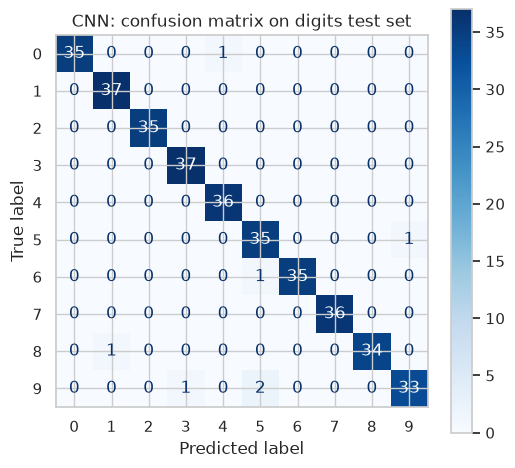

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

cnn.eval()
with torch.no_grad():
    y_pred = cnn(X_test).argmax(1).numpy()

fig, ax = plt.subplots(figsize=(6, 5.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=ax)
ax.set_title("CNN: confusion matrix on digits test set")
plt.show()

Check the printed numbers above: the CNN typically matches or slightly
beats Module 11's MLP, using **fewer** parameters — weight sharing means a
convolutional layer needs far less capacity to represent "detect this
pattern anywhere in the image" than a fully-connected layer does. On tiny
8x8 images that advantage is modest; it becomes dramatic on **larger, more
realistic images**, where flattening to a vector would need a huge number
of parameters (and lose far more spatial structure) than it does here.
Module 15 pushes into exactly that territory with a deeper network and
transfer learning.

## 5. Visualizing Learned Filters & Feature Maps

Unlike section 1's hand-picked Sobel/blur filters, `conv1`'s 8 filters were
entirely learned via backpropagation. Let's look at what patterns they
converged to, and what they do to a real digit.

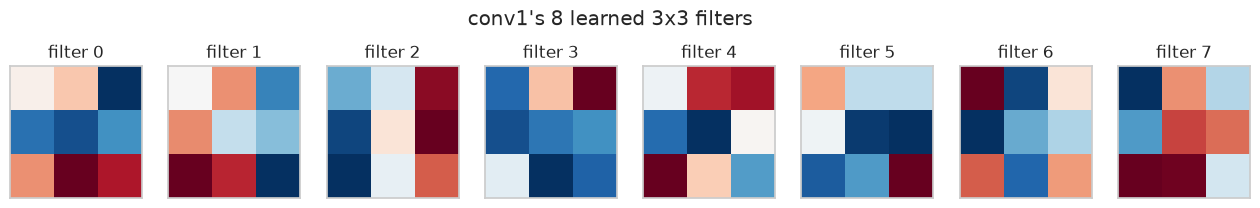

In [10]:
learned_filters = cnn.conv1.weight.detach()  # shape (8, 1, 3, 3)

fig, axes = plt.subplots(1, 8, figsize=(16, 2.2))
for i, ax in enumerate(axes):
    ax.imshow(learned_filters[i, 0], cmap="RdBu")
    ax.set_title(f"filter {i}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("conv1's 8 learned 3x3 filters", y=1.05)
plt.show()

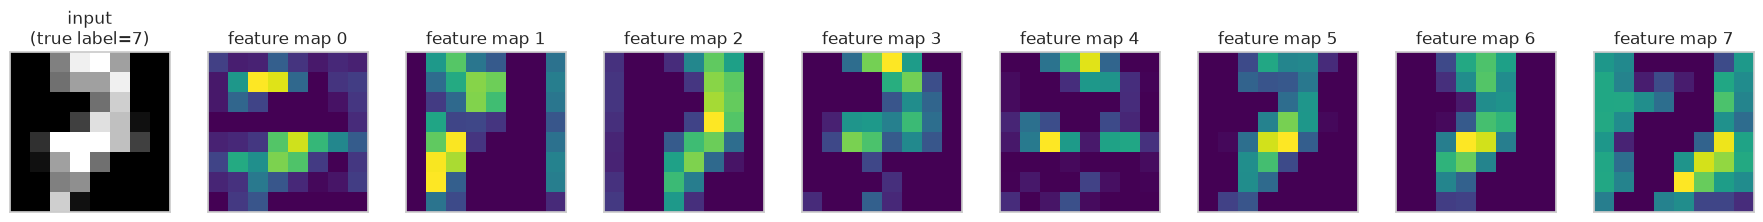

In [11]:
sample_idx = 3
sample = X_test[sample_idx:sample_idx+1]

with torch.no_grad():
    feature_maps = F.relu(cnn.conv1(sample))  # (1, 8, 8, 8)

fig, axes = plt.subplots(1, 9, figsize=(18, 2.2))
axes[0].imshow(sample[0, 0], cmap="gray")
axes[0].set_title(f"input\n(true label={y_test[sample_idx]})")
for i in range(8):
    axes[i + 1].imshow(feature_maps[0, i], cmap="viridis")
    axes[i + 1].set_title(f"feature map {i}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Some filters light up strongly on specific strokes or curves of the digit,
others stay mostly quiet for this particular input — each has specialized
to detect a different local pattern, entirely from gradient descent, with
no hand design at all (contrast this with section 1's manually chosen
Sobel/blur filters).

## Exercises

1. Change `conv1`'s output channels from 8 to 16 (and update `fc`'s input size accordingly) — does test accuracy improve, and does `torchinfo.summary` show a big jump in parameter count?
2. Replace the second `MaxPool2d` with `AvgPool2d` — does final test accuracy change noticeably on this dataset?
3. In section 5, visualize `conv2`'s learned filters (they'll be shape `(16, 8, 3, 3)` — pick one input channel to visualize per filter) — do they look more or less interpretable than `conv1`'s?

## Key Takeaways

- Convolution = a small filter, reused at every position — far fewer parameters than a fully-connected layer over the same input, and naturally translation-invariant.
- Pooling downsamples feature maps, trading some spatial precision for robustness to small shifts and reduced computation in later layers.
- A CNN's filters are learned, not hand-designed — visualizing them (and the feature maps they produce) makes that concrete rather than theoretical.
- On tiny 8x8 images, CNNs and MLPs perform similarly; CNNs earn their advantage on larger, more realistic images, which Module 15 explores with transfer learning.